<center><u><H1>Naive Bayes Classifier</H1></u></center>

In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [2]:
iris = datasets.load_iris()

In [3]:
iris.data[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [4]:
iris.target[:5]

array([0, 0, 0, 0, 0])

## Transforming data:

In [5]:
X = iris.data[:,[2,3]]
Y = iris.target

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=2018)

In [7]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [8]:
cls = GaussianNB()

In [9]:
cls.fit(X_train_std, Y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## Metrics:

In [10]:
print("Accuracy:", accuracy_score(Y_test, cls.predict(X_test_std)))

Accuracy: 0.9777777777777777


In [11]:
print("Confusion matrix: \n", confusion_matrix(Y_test, cls.predict(X_test_std)))

Confusion matrix: 
 [[18  0  0]
 [ 0 11  0]
 [ 0  1 15]]


In [12]:
print("Classification report:\n", classification_report(Y_test, cls.predict(X_test_std)))

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.92      1.00      0.96        11
           2       1.00      0.94      0.97        16

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.97        45
weighted avg       0.98      0.98      0.98        45



## Cross Validation:

In [13]:
from sklearn.model_selection import cross_val_score

In [14]:
cross_val_score(cls, iris.data, iris.target, scoring="accuracy", cv=10)

array([0.93333333, 0.93333333, 1.        , 0.93333333, 0.93333333,
       0.93333333, 0.86666667, 1.        , 1.        , 1.        ])

In [15]:
cross_val_score(cls, iris.data, iris.target, scoring="accuracy", cv=10).mean()

np.float64(0.9533333333333334)

## Printing Data and Decision Boundaries

In [16]:
import Plotting_Decision_Boundaries as db

In [17]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((Y_train, Y_test))

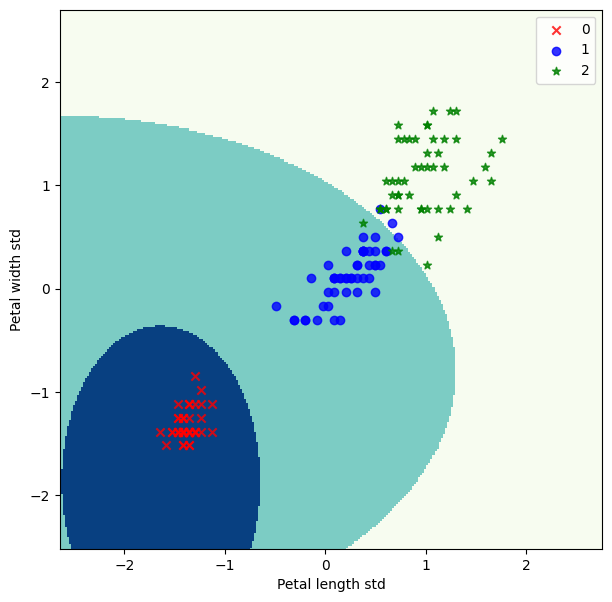

In [18]:
db.printing_db(X=X_combined_std, y=y_combined, model=cls)

## Reference:

http://scikit-learn.org/stable/modules/naive_bayes.html